In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [32]:
dados_vendas = {
    'mes': [
      'Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho',  'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'
    ],
    'vendas': [
       2000, 2200, 2300, 2500, 2600, 2700,
       2800, 2900, 3000, 3100, 3200, 3300
    ]
}

In [33]:
df_vendas = pd.DataFrame(dados_vendas)
df_vendas.head(12)

,mes,vendas
0,Janeiro,2000
1,Fevereiro,2200
2,Março,2300
3,Abril,2500
4,Maio,2600
5,Junho,2700
6,Julho,2800
7,Agosto,2900
8,Setembro,3000
9,Outubro,3100


In [34]:
df_vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   mes     12 non-null     str  
 1   vendas  12 non-null     int64
dtypes: int64(1), str(1)
memory usage: 324.0 bytes


In [35]:
# One-hot encoding para a coluna 'mes' - Aqui eu poderia tratar os meses indo de 1 a 12 normalmente, porém, para treinamento de modelos há
# um problema. O modelo pode interpretar que o mês 12 é maior que o mês 1, e isso não é verdade. Então, para evitar esse problema, eu vou fazer
# a codificação one-hot, que seria criar uma coluna para cada mês, e colocar 1 ou 0 dependendo se o mês é aquele ou não.
df_vendas = pd.get_dummies(df_vendas, columns=['mes'], dtype='int64')
df_vendas.head(12)

,vendas,mes_Abril,mes_Agosto,mes_Dezembro,mes_Fevereiro,mes_Janeiro,mes_Julho,mes_Junho,mes_Maio,mes_Março,mes_Novembro,mes_Outubro,mes_Setembro
0,2000,0,0,0,0,1,0,0,0,0,0,0,0
1,2200,0,0,0,1,0,0,0,0,0,0,0,0
2,2300,0,0,0,0,0,0,0,0,1,0,0,0
3,2500,1,0,0,0,0,0,0,0,0,0,0,0
4,2600,0,0,0,0,0,0,0,1,0,0,0,0
5,2700,0,0,0,0,0,0,1,0,0,0,0,0
6,2800,0,0,0,0,0,1,0,0,0,0,0,0
7,2900,0,1,0,0,0,0,0,0,0,0,0,0
8,3000,0,0,0,0,0,0,0,0,0,0,0,1
9,3100,0,0,0,0,0,0,0,0,0,0,1,0


In [36]:
X = df_vendas.drop('vendas', axis=1)
y = df_vendas['vendas']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=51)

In [38]:
model_vendas = LinearRegression().fit(X_train, y_train)

In [39]:
y_pred = model_vendas.predict(X_test)

In [40]:
model_vendas.score(X_train, y_train)

1.0

In [41]:
model_vendas.score(X_test, y_test)

-0.6428571428571419

In [42]:
mean_absolute_error(y_test, y_pred)

288.88888888888886

In [ ]:
dezembro = pd.DataFrame(columns=X.columns)
dezembro.loc[0] = 0
dezembro['mes_Dezembro'] = 1
venda_dezembro = model_vendas.predict(dezembro)
print(f"Previsão de vendas para dezembro: {venda_dezembro[0]:.0f}")

Previsão de vendas para dezembro: 3300


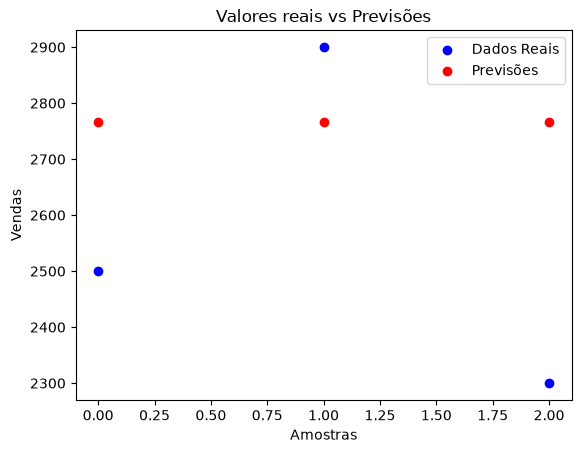

In [43]:
plt.scatter(range(len(y_test)), y_test, color='blue', label='Dados Reais')
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Previsões')

plt.xlabel('Amostras')
plt.ylabel('Vendas')
plt.title('Valores reais vs Previsões')
plt.legend()
plt.show()

In [46]:
df_vendas_original = pd.DataFrame(dados_vendas)
resultado = pd.DataFrame({
    'Mes': df_vendas_original.loc[y_test.index, 'mes'],
    'Real': y_test,
    'Previsto': y_pred
})

resultado

,Mes,Real,Previsto
3,Abril,2500,2766.666667
7,Agosto,2900,2766.666667
2,Março,2300,2766.666667


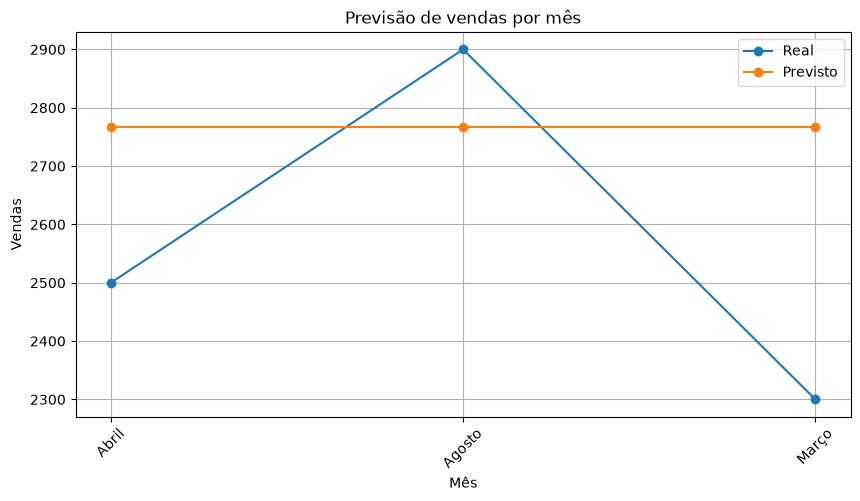

In [47]:
plt.figure(figsize=(10,5))

plt.plot(resultado['Mes'], resultado['Real'], 
         marker='o', label='Real')

plt.plot(resultado['Mes'], resultado['Previsto'], 
         marker='o', label='Previsto')

plt.xticks(rotation=45)
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.title('Previsão de vendas por mês')
plt.legend()
plt.grid(True)

plt.show()

array([[<Axes: title={'center': 'vendas'}>,
        <Axes: title={'center': 'mes_Abril'}>,
        <Axes: title={'center': 'mes_Agosto'}>,
        <Axes: title={'center': 'mes_Dezembro'}>],
       [<Axes: title={'center': 'mes_Fevereiro'}>,
        <Axes: title={'center': 'mes_Janeiro'}>,
        <Axes: title={'center': 'mes_Julho'}>,
        <Axes: title={'center': 'mes_Junho'}>],
       [<Axes: title={'center': 'mes_Maio'}>,
        <Axes: title={'center': 'mes_Março'}>,
        <Axes: title={'center': 'mes_Novembro'}>,
        <Axes: title={'center': 'mes_Outubro'}>],
       [<Axes: title={'center': 'mes_Setembro'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

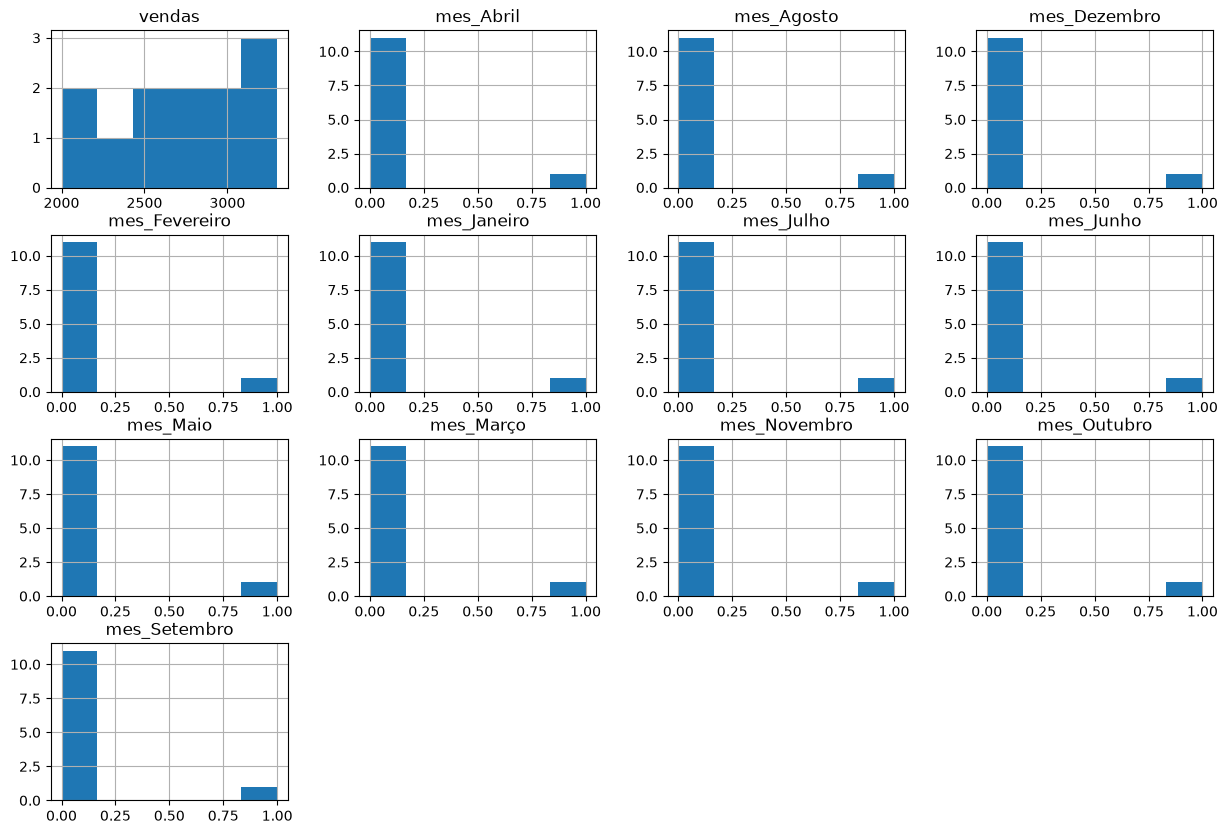

In [62]:
df_vendas.hist(layout=(4, 4), figsize=(15, 10), bins=6)